In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/unemployment_india.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


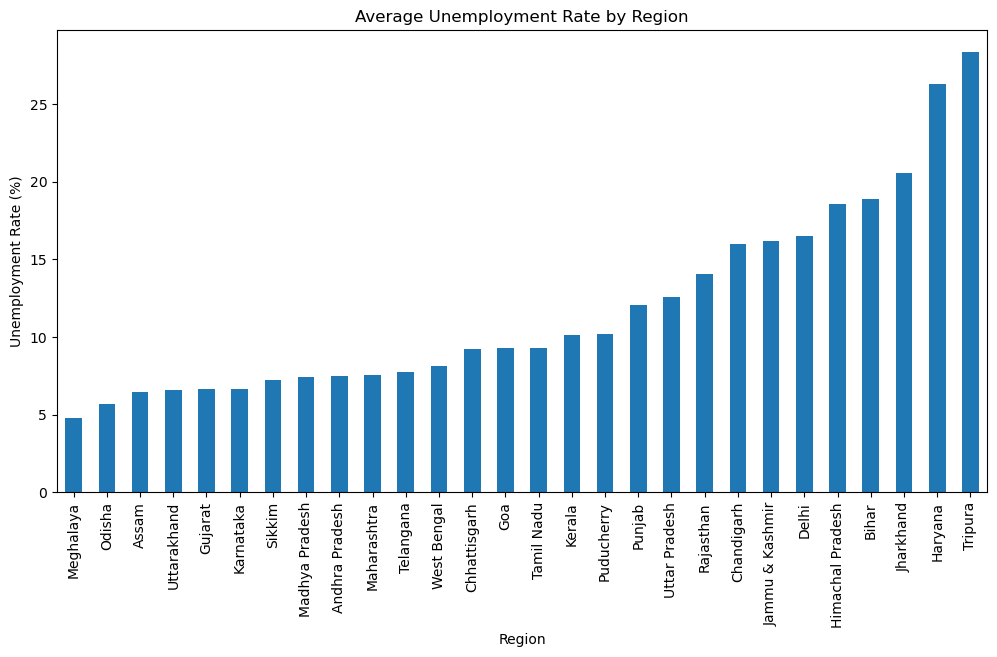

In [6]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

plt.figure(figsize=(12,6))
region_avg.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")
plt.savefig("../images/region_unemployment.png")
plt.show()

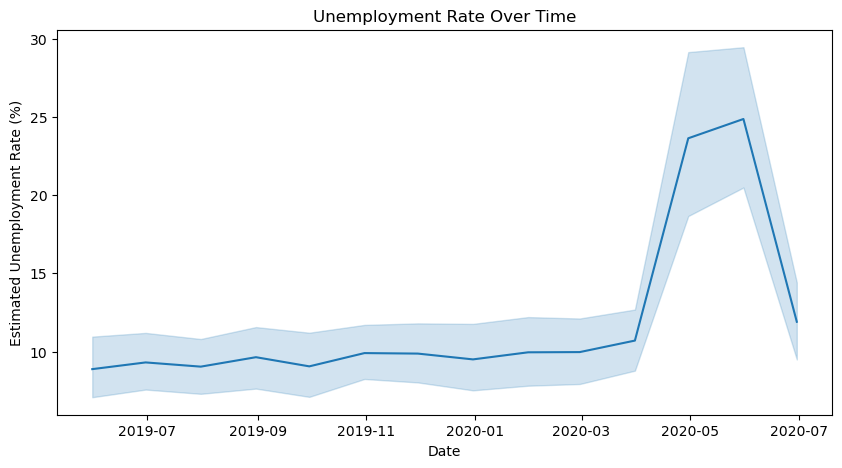

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Date",y="Estimated Unemployment Rate (%)",data=df)

plt.title("Unemployment Rate Over Time")
plt.savefig("../images/unemployment_trend.png")
plt.show()

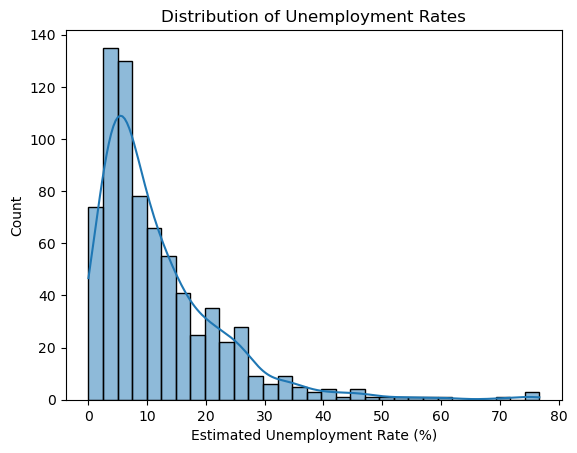

In [8]:
sns.histplot(df["Estimated Unemployment Rate (%)"],kde=True)

plt.title("Distribution of Unemployment Rates")
plt.savefig("../images/distribution.png")
plt.show()

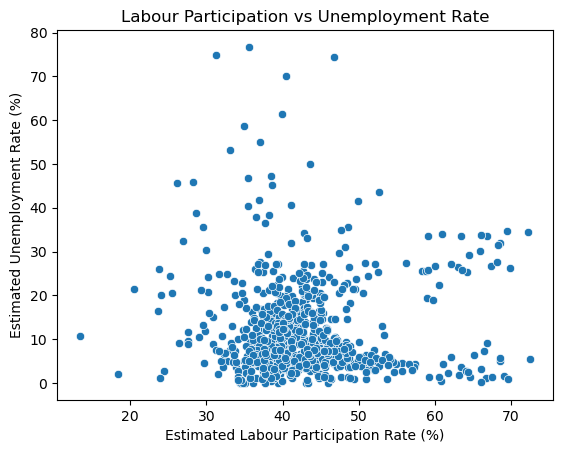

In [9]:
sns.scatterplot(
x="Estimated Labour Participation Rate (%)",
y="Estimated Unemployment Rate (%)",
data=df
)

plt.title("Labour Participation vs Unemployment Rate")
plt.savefig("../images/participation_vs_unemployment.png")
plt.show()

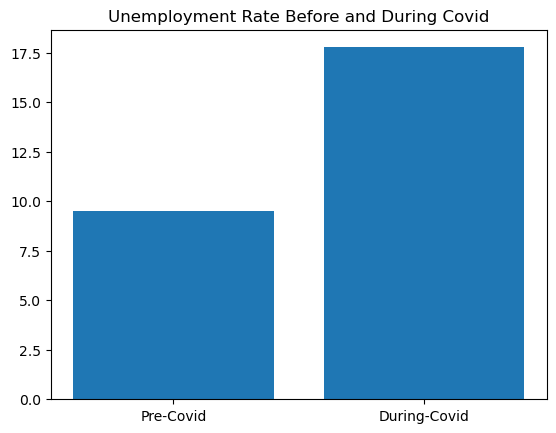

In [10]:
covid_date = "2020-03-01"

pre_covid = df[df["Date"] < covid_date]
during_covid = df[df["Date"] >= covid_date]

values = [
pre_covid["Estimated Unemployment Rate (%)"].mean(),
during_covid["Estimated Unemployment Rate (%)"].mean()
]

labels = ["Pre-Covid","During-Covid"]

plt.bar(labels,values)

plt.title("Unemployment Rate Before and During Covid")
plt.savefig("../images/covid_comparison.png")
plt.show()

Insights:

• Unemployment rates increased significantly during COVID-19.
• Some regions show consistently higher unemployment.
• Labour participation rate affects unemployment patterns.
• Economic disruptions during lockdown caused a sharp spike.